# Stage 08 — Advanced Analysis & Robustness Checks

Stage 05 remains the primary analysis. This supporting notebook checks covariate-adjusted estimates, randomization-style permutation inference, and extreme-spend diagnostics without changing the estimand or data. Adjustment uses only pre-treatment covariates; post-treatment visit, conversion, and spend are never adjustment covariates.

Adjusted effects


,Outcome,Treatment,Adjusted Estimate,Adjusted CI Lower,Adjusted CI Upper,Adjusted P-Value,Method
0,Conversion,Mens E-Mail,0.007967,0.005418,0.010515,0.000000,Logistic AME HC3
1,Conversion,Womens E-Mail,0.004336,0.001825,0.006846,0.000713,Logistic AME HC3
2,Visit,Mens E-Mail,0.083518,0.075776,0.091260,0.000000,Logistic AME HC3
3,Visit,Womens E-Mail,0.053105,0.045444,0.060766,0.000000,Logistic AME HC3
4,Spend,Mens E-Mail,0.764007,0.479276,1.048739,0.000000,OLS HC3
5,Spend,Womens E-Mail,0.425887,0.170341,0.681432,0.001089,OLS HC3


Extreme threshold: 499.0


,Scenario,Treatment,Spend Effect
0,Full sample,Mens E-Mail,0.769827
1,Full sample,Womens E-Mail,0.424412
2,Winsorized positive 99.5%,Mens E-Mail,0.769827
3,Winsorized positive 99.5%,Womens E-Mail,0.424412
4,Exclude top 5,Mens E-Mail,0.723117
5,Exclude top 5,Womens E-Mail,0.354558
6,Exclude top 10,Mens E-Mail,0.699820
7,Exclude top 10,Womens E-Mail,0.401342
8,Exclude top 20,Mens E-Mail,0.637502
9,Exclude top 20,Womens E-Mail,0.378822


FDR-notable Stage 07 hypotheses


,Outcome,Treatment,Segment Variable,Raw P-Value,FDR Adjusted P-Value,Interpretation
20,Conversion,Womens E-Mail,newbie,0.001489,0.010722,Exploratory interaction notable after FDR adju...
26,Visit,Mens E-Mail,newbie,0.000482,0.004342,Exploratory interaction notable after FDR adju...
31,Visit,Womens E-Mail,zip_code,0.004845,0.029072,Exploratory interaction notable after FDR adju...
32,Visit,Womens E-Mail,newbie,0.000057,0.000681,Exploratory interaction notable after FDR adju...
34,Visit,Womens E-Mail,mens,0.000000,0.000000,Exploratory interaction notable after FDR adju...
35,Visit,Womens E-Mail,womens,0.000000,0.000000,Exploratory interaction notable after FDR adju...


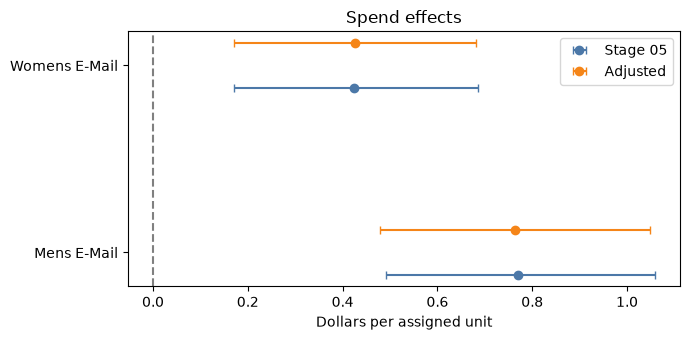

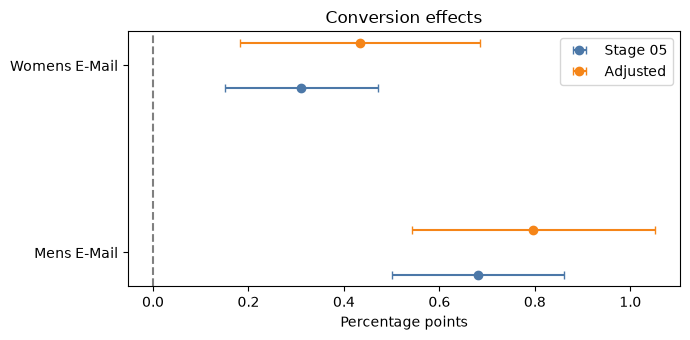

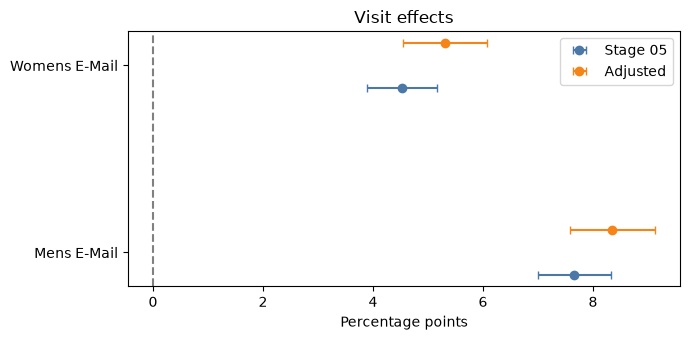

VIF design check: categorical reference coding is used; no variables removed mechanically.
Raw unchanged: True Processed unchanged: True


In [1]:
from pathlib import Path
from hashlib import sha256
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

root=Path('.')
if not (root/'data/processed/Hillstrom_clean.csv').exists(): root=Path('..')
raw_path=root/'data/raw/Hillstrom.csv'; processed_path=root/'data/processed/Hillstrom_clean.csv'; figdir=root/'outputs/figures'; tdir=root/'outputs/tables'
digest=lambda p:sha256(p.read_bytes()).hexdigest(); raw0,proc0=digest(raw_path),digest(processed_path)
d=pd.read_csv(processed_path); primary=pd.read_csv(tdir/'primary_treatment_effects.csv'); it=pd.read_csv(tdir/'interaction_tests.csv')
d['mens_email']=(d.segment=='Mens E-Mail').astype(int); d['womens_email']=(d.segment=='Womens E-Mail').astype(int)
terms='mens_email + womens_email + recency + history + C(history_segment) + mens + womens + C(zip_code) + newbie + C(channel)'; pairs=[('Mens E-Mail','mens_email'),('Womens E-Mail','womens_email')]

# Logistic AMEs and robust OLS treatment coefficients.
adj=[]
for outcome in ['conversion','visit']:
 m=smf.logit('{} ~ {}'.format(outcome,terms),data=d).fit(disp=False,cov_type='HC3'); ame=m.get_margeff(at='overall',method='dydx',dummy=True).summary_frame()
 for treatment,term in pairs:
  k=[x for x in ame.index if term in str(x)][0]; adj.append([outcome.title(),treatment,ame.loc[k,'dy/dx'],ame.loc[k,'Conf. Int. Low'],ame.loc[k,'Cont. Int. Hi.'],ame.loc[k,'Pr(>|z|)'],'Logistic AME HC3'])
ols=smf.ols('spend ~ {}'.format(terms),data=d).fit(cov_type='HC3')
for treatment,term in pairs:
 ci=ols.conf_int().loc[term]; adj.append(['Spend',treatment,ols.params[term],ci.iloc[0],ci.iloc[1],ols.pvalues[term],'OLS HC3'])
adj=pd.DataFrame(adj,columns=['Outcome','Treatment','Adjusted Estimate','Adjusted CI Lower','Adjusted CI Upper','Adjusted P-Value','Method'])
out=primary.merge(adj,on=['Outcome','Treatment']); out['Unadjusted CI Width']=out['CI Upper']-out['CI Lower']; out['Adjusted CI Width']=out['Adjusted CI Upper']-out['Adjusted CI Lower']; out['CI Width Reduction (%)']=(1-out['Adjusted CI Width']/out['Unadjusted CI Width'])*100; out['Sensitivity Estimate']=out['Adjusted Estimate']; out['Permutation P-Value']=np.nan

# 10,000 label permutations for spend.
rng=np.random.default_rng(20260918)
for treatment,term in pairs:
 x=d.loc[d.segment.isin(['No E-Mail',treatment]),['segment','spend']]; observed=x.loc[x.segment==treatment,'spend'].mean()-x.loc[x.segment=='No E-Mail','spend'].mean(); values=x.spend.to_numpy(); nt=(x.segment==treatment).sum(); hits=0
 for _ in range(10000):
  perm=rng.permutation(values); hits += abs(perm[:nt].mean()-perm[nt:].mean())>=abs(observed)
 out.loc[(out.Outcome=='Spend')&(out.Treatment==treatment),'Permutation P-Value']=(hits+1)/10001

# Extreme-spend diagnostics: positive-spender 99.5th percentile and leave-top-global-out.
threshold=d.loc[d.spend>0,'spend'].quantile(.995); sens=[]
for label,frame in [('Full sample',d),('Winsorized positive 99.5%',d.assign(spend=d.spend.clip(upper=threshold)))]:
 for treatment,_ in pairs: sens.append([label,treatment,frame.loc[frame.segment==treatment,'spend'].mean()-frame.loc[frame.segment=='No E-Mail','spend'].mean()])
for n in [5,10,20]:
 frame=d.drop(d.nlargest(n,'spend').index)
 for treatment,_ in pairs: sens.append(['Exclude top {}'.format(n),treatment,frame.loc[frame.segment==treatment,'spend'].mean()-frame.loc[frame.segment=='No E-Mail','spend'].mean()])
sens=pd.DataFrame(sens,columns=['Scenario','Treatment','Spend Effect'])

# Stage 07 follow-up only; no new subgroup search.
follow=it.loc[it['FDR Adjusted P-Value']<.05,['Outcome','Treatment','Segment Variable','Raw P-Value','FDR Adjusted P-Value','Interpretation']]
print('Adjusted effects'); display(adj.round(6)); print('Extreme threshold:',threshold); display(sens.round(6)); print('FDR-notable Stage 07 hypotheses'); display(follow.round(6))
summary=out[['Outcome','Treatment','Absolute Effect','Adjusted Estimate','Adjusted CI Lower','Adjusted CI Upper','Adjusted P-Value','Permutation P-Value','Sensitivity Estimate','Method']].rename(columns={'Absolute Effect':'Primary Estimate','Method':'Notes'}); summary.to_csv(tdir/'robustness_analysis_summary.csv',index=False)

# Separate-unit figures.
for outcome,filename,scale in [('Spend','adjusted_vs_unadjusted_spend.png',1),('Conversion','adjusted_vs_unadjusted_binary.png',100),('Visit','adjusted_vs_unadjusted_binary.png',100)]:
 p=out[out.Outcome==outcome]; fig,ax=plt.subplots(figsize=(7,3.5)); y=np.arange(2)
 for est,lo,hi,label,color,off in [('Absolute Effect','CI Lower','CI Upper','Stage 05','#4C78A8',-.12),('Adjusted Estimate','Adjusted CI Lower','Adjusted CI Upper','Adjusted','#F58518',.12)]:
  z=p[est].to_numpy()*scale; ax.errorbar(z,y+off,xerr=np.vstack([z-p[lo].to_numpy()*scale,p[hi].to_numpy()*scale-z]),fmt='o',label=label,color=color,capsize=3)
 ax.axvline(0,color='gray',ls='--'); ax.set_yticks(y,p.Treatment); ax.set_title(outcome+' effects'); ax.set_xlabel('Dollars per assigned unit' if outcome=='Spend' else 'Percentage points'); ax.legend(); plt.tight_layout(); fig.savefig(figdir/filename,dpi=160,bbox_inches='tight'); plt.show()
print('VIF design check: categorical reference coding is used; no variables removed mechanically.')
print('Raw unchanged:',raw0==digest(raw_path),'Processed unchanged:',proc0==digest(processed_path))

## Stage 08 Findings

Stage 05 remains primary. This notebook reports adjusted supporting estimates, permutation p-values, and secondary extreme-value diagnostics. Covariate adjustment cannot repair unobserved data limitations. Spend remains zero-inflated; conditional purchaser amounts are not separately interpreted as causal. The six Stage 07 FDR-notable interactions are hypothesis-generating only and suitable for prospective validation, not targeting. No final business recommendation is made.